<a href="https://colab.research.google.com/github/aainabatool/IPKI-Machine-Learning-Course/blob/main/W02_L01_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression:**

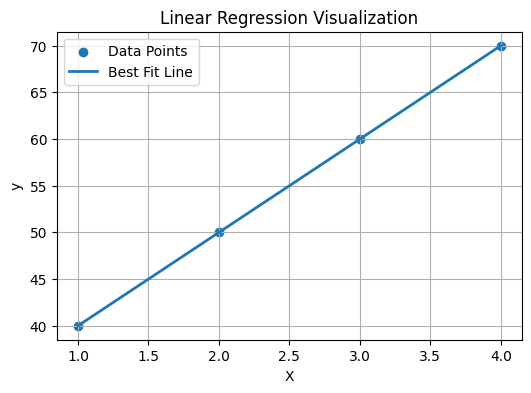

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Dataset
X = np.array([[1], [2], [3], [4]])
y = np.array([40, 50, 60, 70])

# Train Linear Regression
model = LinearRegression()
model.fit(X, y)

# Line for visualization
x_line = np.linspace(1, 4, 100).reshape(-1, 1)
y_line = model.predict(x_line)

# Plot
plt.figure(figsize=(6,4))
plt.scatter(X, y, label="Data Points")
plt.plot(x_line, y_line, label="Best Fit Line", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Visualization")
plt.legend()
plt.grid(True)
plt.show()


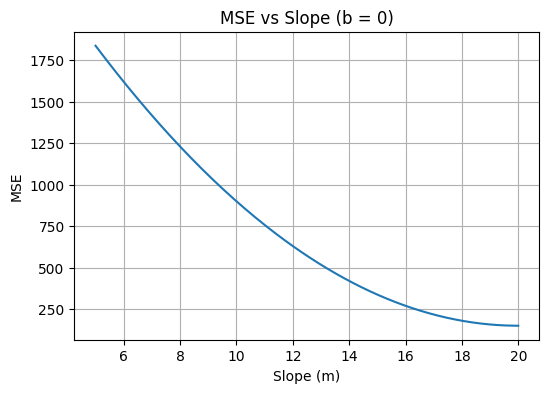

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([1,2,3,4])
y = np.array([40,50,60,70])

# Try many slopes (m values)
ms = np.linspace(5, 20, 200)
errors = []

for m in ms:
    y_pred = m * X   # assume b = 0 for simplicity
    mse = np.mean((y_pred - y)**2)
    errors.append(mse)

plt.figure(figsize=(6,4))
plt.plot(ms, errors)
plt.xlabel("Slope (m)")
plt.ylabel("MSE")
plt.title("MSE vs Slope (b = 0)")
plt.grid(True)
plt.show()


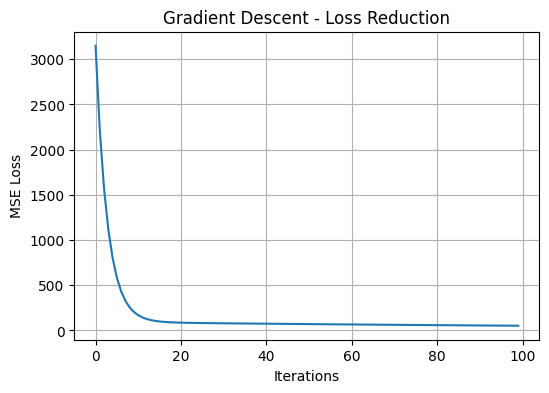

Learned m: 16.008097976747447
Learned b: 12.33545859211026


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([1,2,3,4])
y = np.array([40,50,60,70])

# Gradient Descent parameters
m = 0     # start with random value
b = 0
lr = 0.01
iterations = 100

m_history = []
loss_history = []

for i in range(iterations):
    y_pred = m*X + b

    # Compute gradients
    dm = (-2/len(X)) * sum(X * (y - y_pred))
    db = (-2/len(X)) * sum(y - y_pred)

    # Update
    m = m - lr * dm
    b = b - lr * db

    # Track history
    m_history.append(m)
    loss_history.append(np.mean((y - y_pred)**2))

# Plot loss curve
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent - Loss Reduction")
plt.grid(True)
plt.show()

print("Learned m:", m)
print("Learned b:", b)


# **House Price Prediction**


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
# Load Dataset
# -------------------------
df = pd.read_csv('/content/data.csv')

In [15]:
# -------------------------
# Select Features
# -------------------------
features = [
    "sqft_living", "bedrooms", "bathrooms", "floors",
    "sqft_lot", "sqft_above", "sqft_basement",
    "waterfront", "view", "condition",
    "yr_built", "yr_renovated"
]

X = df[features]
y = df["price"]


In [16]:
# Train-Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [17]:
# -------------------------
# Feature Scaling
# -------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [18]:
# -------------------------
# Train Linear Regression
# -------------------------
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model Coefficients:\n", model.coef_)
print("Intercept:", model.intercept_)

Model Coefficients:
 [137261.99018735 -58602.84976238  28620.33246853  37618.80721879
 -18290.06685691 120011.21608762  61340.47036158  32639.57847034
  34595.80025051  19810.03009605 -76458.84307742   8083.94534664]
Intercept: 544848.2688325457


In [19]:
# -------------------------
# Predictions
# -------------------------
y_pred = model.predict(X_test_scaled)

In [20]:
# -------------------------
# Evaluation
# -------------------------
mae = mean_absolute_error(y_test, y_pred)  #avg absolute mistake
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\nEvaluation Metrics")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", np.sqrt(mse))
print("R² Score:", r2)



Evaluation Metrics
MAE: 210908.17325011527
MSE: 986921767056.1313
RMSE: 993439.3625461654
R² Score: 0.03228385663277078


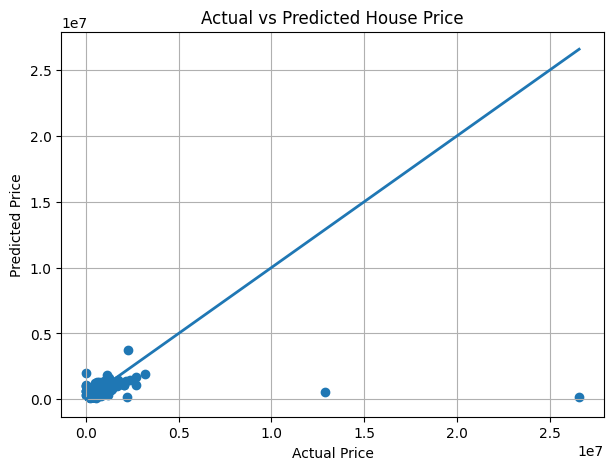

In [21]:
# -------------------------
# Visualization
# -------------------------
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    linewidth=2
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.grid(True)
plt.show()

# **Polynomial Regression:**

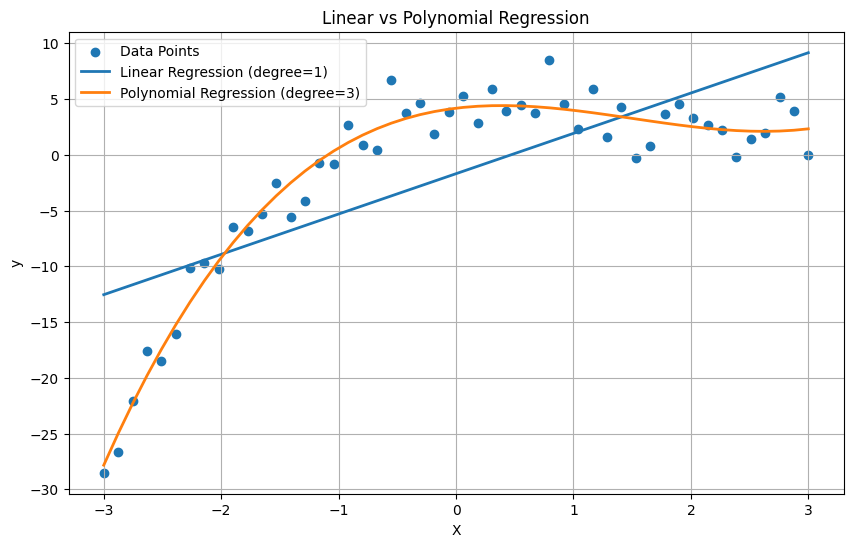

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# ---- 1. Generate curved dataset ----
np.random.seed(42)
X = np.linspace(-3, 3, 50).reshape(-1, 1)
y = 0.5*X**3 - 2*X**2 + X + 5 + np.random.randn(*X.shape)*2
y = y.ravel()

# ---- 2. Fit linear regression ----
linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)

# ---- 3. Fit polynomial regression (degree = 3) ----
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_pred_poly = poly_model.predict(X_poly)

# ---- 4. Plot both curves ----
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label="Data Points")

plt.plot(X, y_pred_linear, label="Linear Regression (degree=1)", linewidth=2)
plt.plot(X, y_pred_poly, label="Polynomial Regression (degree=3)", linewidth=2)

plt.title("Linear vs Polynomial Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
